<h2>Evaluación del desempeño de SVM en la clasificación de imágenes de perros y gatos - Aprendizaje Automático 2-2024</h2>

* <h5>Nombre: Xavier Muñoz Díaz</h3>
* <h5>Profesora: Violeta Chang Camacho</h3>
* <h5>Ayudante: Marcelo Guzmán</h3>

<h3>Definiciones</h3>

- SVM: Se emplean comúnmente en problemas de clasificación. Distinguen entre dos clases encontrando el hiperplano óptimo que maximiza el margen entre los puntos de datos más cercanos de clases opuestas (IBM, 2023a).

- SVM no lineales: Se utiliza con datos que no son linealmente separables y se aplican métodos de preprocesamiento a los datos de entrenamiento para transformarlos en un espacio de características de mayor dimensión (IBM, 2023a). 

- PCA: Reduce la cantidad de dimensiones en grandes conjuntos de datos a componentes principales que conservan la mayor parte de la información original (IBM, 2023b). 

En el laboratorio se utilizan los siguientes kernels:
- Kernel lineal: Es un producto escalar simple entre los vectores de características de entrada y es adecuado para datos linealmente separables (Academy, 2023).

- Kernel RBF: Según Sreenivasa (2021), sirve para conjuntos de datos no lineales y opera midiendo la similitud entre puntos de datos en función de su distancia euclidiana en el espacio de entrada (GeeksforGeeks, 2024).

<h3>Actividades a desarrollar</h3>

El objetivo de este laboratorio es evaluar el desempeño de un clasificador SVM para la clasificación de imágenes de perros y gatos. Para ello, se utilizará el conjunto de datos Cats & Dogs.

Para llevar a cabo este análisis, se realizarán dos experimentos en los que se variarán las estrategias de generación de vectores de características a partir de las imágenes:

1) Entrenar una SVM usando un kernel RBF y un kernel alternativo, transformando las imágenes de tamaño unificado directamente en vectores.

2) Similar al experimento anterior pero con la diferencia que se debe aplicar PCA para reducir los vectores a 256 dimensiones.

Los datos de entrenamiento incluirán 4000 imágenes de cada clase, y el conjunto de prueba incluirá 1000 imágenes de cada clase. Los resultados se analizarán en términos de precisión, tanto para cada categoría como a nivel global, y se presentarán mediante tablas y gráficos.

<h3>Importaciones de Librerias</h3>

In [12]:
import os
import cv2
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import time

<h3>Carga de datasets de entrenamiento y prueba, y etiquetado</h3>

In [19]:
'''
Descripción: Carga imágenes en escala de grises (por simplicidad) desde una carpeta, redimensionándolas a un tamaño (para reducir costo computacional)
              También asigna etiquetas a las imágenes según su clase (gatos o perros).
Entrada:
    - ruta (str): Ruta al directorio base que contiene subcarpetas 'cats' y 'dogs' con imágenes en formato JPG.
    - tamanyo (tuple): Tamaño al que se redimensionarán las imágenes
#
Salida:
    - imagenes : Arreglo con las imágenes procesadas y aplanadas en vectores.
    - etiquetas : Arreglo con las etiquetas de las imágenes, donde 0 representa gatos y 1 representa perros.
'''

def cargar_imagenes(ruta):
    tamanyo = (64, 64)
    etiquetas = []
    imagenes = []
    for clase in ['cats', 'dogs']:
        ruta_clase = os.path.join(ruta, clase)
        etiqueta = 0 if clase == 'cats' else 1
        for archivo in os.listdir(ruta_clase):
            if not archivo.lower().endswith(('.jpg')):
                continue

            ruta_imagen = os.path.join(ruta_clase, archivo)
            imagen = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
            
            if imagen is None:
                print(f"No se pudo cargar la imagen: {ruta_imagen}")
                continue
            
            imagen = cv2.resize(imagen, tamanyo)
            imagenes.append(imagen.flatten())
            etiquetas.append(etiqueta)
            
    return np.array(imagenes), np.array(etiquetas)

ruta_entrenamiento = 'training_set'
ruta_prueba = 'valid_set'
imagenes_entrenamiento, etiquetas_entrenamiento = cargar_imagenes(ruta_entrenamiento)
imagenes_prueba, etiquetas_prueba = cargar_imagenes(ruta_prueba)

<h3>Evaluación del modelo</h3>

In [ ]:
'''
Descripción: Entrena un modelo de clasificación utilizando un conjunto de datos de entrenamiento,
    y luego evalúa su desempeño en un conjunto de prueba. Imprime la precisión, un reporte de clasificación,
    y la matriz de confusión, además de medir el tiempo que tarda en entrenarse el modelo.
Entrada:
    - pipeline: Objeto de pipeline de sklearn.
    - datos_entrenamiento: Datos de entrenamiento en formato de matriz.
    - datos_prueba: Datos de prueba en formato de matriz.
    - etiquetas_entrenamiento: Etiquetas para el conjunto de datos de entrenamiento.
    - etiquetas_prueba: Etiquetas para el conjunto de datos de prueba.
    - nombre_kernel (str): Nombre del kernel utilizado para diferenciar los prints.
Salida:
- precision (float): Precisión del modelo en el conjunto de prueba.
- predicciones: Predicciones realizadas por el modelo sobre el conjunto de prueba.
- matriz_confusion: Matriz de confusión.
- tiempo_compilacion (float): Tiempo de entrenamiento y prueba del modelo en segundos.
'''
def evaluar_modelo(pipeline, datos_entrenamiento, datos_prueba, etiquetas_entrenamiento, etiquetas_prueba, nombre_kernel):
    inicio_tiempo = time.time()

    pipeline.fit(datos_entrenamiento, etiquetas_entrenamiento)
    predicciones = pipeline.predict(datos_prueba)
    
    fin_tiempo = time.time()  # Fin del temporizador
    tiempo_compilacion = fin_tiempo - inicio_tiempo

    precision = accuracy_score(etiquetas_prueba, predicciones)

    print(f"Precisión en conjunto de prueba con kernel {nombre_kernel}: {precision}")
    print(f"Reporte de Clasificación para kernel {nombre_kernel}:")
    print(classification_report(etiquetas_prueba, predicciones, target_names=['Gatos', 'Perros']))
    
    matriz_confusion = confusion_matrix(etiquetas_prueba, predicciones)
    print(f"Matriz de Confusión para kernel {nombre_kernel}:")
    print(matriz_confusion)
    
    return precision, predicciones, matriz_confusion, tiempo_compilacion


<h2>Experimento 1</h2>
A continuación, se procede a probar el modelo con un kernel RBF y lineal para vectores correspondientes a las imágenes de tamaño unificado convertidas a vectores.

In [15]:
pipeline_svm_rbf = Pipeline([
    ('escalador', StandardScaler()), 
    ('svm_rbf', SVC(kernel='rbf', gamma=0.000625)) 
])


pipeline_svm_linear = Pipeline([
    ('escalador', StandardScaler()),  
    ('svm_linear', SVC(kernel='linear', gamma=0.0006251))
])

accuracy_rbf, predicciones_rbf, matriz_confusion_rbf, tiempo_compilacion_rbf = evaluar_modelo(
    pipeline_svm_rbf, imagenes_entrenamiento, imagenes_prueba, etiquetas_entrenamiento, etiquetas_prueba, nombre_kernel="RBF"
)
print(f"Tiempo de compilación para el modelo con kernel RBF: {tiempo_compilacion_rbf:.4f} segundos")

accuracy_linear, predicciones_linear, matriz_confusion_linear, tiempo_compilacion_linear = evaluar_modelo(
    pipeline_svm_linear, imagenes_entrenamiento, imagenes_prueba, etiquetas_entrenamiento, etiquetas_prueba, nombre_kernel="Linear"
)
print(f"Tiempo de compilación para el modelo con kernel Linear: {tiempo_compilacion_linear:.4f} segundos")


Precisión en conjunto de prueba con kernel RBF: 0.6500247157686604
Reporte de Clasificación para kernel RBF:
              precision    recall  f1-score   support

       Gatos       0.65      0.65      0.65      1011
      Perros       0.65      0.65      0.65      1012

    accuracy                           0.65      2023
   macro avg       0.65      0.65      0.65      2023
weighted avg       0.65      0.65      0.65      2023

Matriz de Confusión para kernel RBF:
[[657 354]
 [354 658]]
Tiempo de compilación para el modelo con kernel RBF: 218.5290 segundos
Precisión en conjunto de prueba con kernel Linear: 0.5096391497775581
Reporte de Clasificación para kernel Linear:
              precision    recall  f1-score   support

       Gatos       0.51      0.52      0.52      1011
      Perros       0.51      0.50      0.50      1012

    accuracy                           0.51      2023
   macro avg       0.51      0.51      0.51      2023
weighted avg       0.51      0.51      0.51   

<h3>Gráficos de Accuaracy por categoría</h3>


In [27]:
'''
Descripción: Calcula y presenta el accuracy por categoría (gatos y perros), el accuracy total y el tiempo de ejecución
en forma de tabla y gráficos de barras.
Entrada:
    - matriz_confusion_rbf: Matriz de confusión del modelo SVM con kernel RBF.
    - matriz_confusion_linear: Matriz de confusión del modelo SVM con kernel Linear.
    - accuracy_rbf (float): Precisión total del modelo con kernel RBF.
    - accuracy_linear (float): Precisión total del modelo con kernel Linear.
    - tiempo_compilacion_rbf (float): Tiempo de ejecución del modelo con kernel RBF en segundos.
    - tiempo_compilacion_linear (float): Tiempo de ejecución del modelo con kernel Linear en segundos.
Salida: No retorna ningún valor; muestra los resultados directamente en la consola y en gráficos.
'''
def mostrar_resultados_svm(matriz_confusion_rbf, matriz_confusion_linear, accuracy_rbf, accuracy_linear, tiempo_compilacion_rbf, tiempo_compilacion_linear):
    categorias = ['Cats', 'Dogs']
    
    accuracies_rbf = np.diag(matriz_confusion_rbf) / np.sum(matriz_confusion_rbf, axis=1)
    accuracies_linear = np.diag(matriz_confusion_linear) / np.sum(matriz_confusion_linear, axis=1)

    accuracy_total_rbf = accuracy_rbf
    accuracy_total_linear = accuracy_linear
    tiempo_ejecucion_rbf = tiempo_compilacion_rbf
    tiempo_ejecucion_linear = tiempo_compilacion_linear

    tabla_resultados = pd.DataFrame({
        '': ['Accuracy cats', 'Accuracy dogs', 'Accuracy total', 'Tiempo de ejecución [s]'],
        'SVM kernel RBF': [accuracies_rbf[0], accuracies_rbf[1], accuracy_total_rbf, tiempo_ejecucion_rbf],
        'SVM kernel Linear': [accuracies_linear[0], accuracies_linear[1], accuracy_total_linear, tiempo_ejecucion_linear]
    })
    print("Tabla de resultados:")
    print(tabla_resultados)

    plt.figure(figsize=(12, 6))
    x = np.arange(len(categorias))

    plt.subplot(1, 2, 1)
    barras_rbf = plt.bar(x, accuracies_rbf, color='skyblue')
    plt.xticks(x, categorias)
    plt.ylim(0, 1)
    plt.title('Accuracy por categoría - Kernel RBF')
    plt.xlabel('Categoría')
    plt.ylabel('Accuracy')
    for barra in barras_rbf:
        yval = barra.get_height()
        plt.text(barra.get_x() + barra.get_width() / 2, yval + 0.01, f"{yval:.2f}", ha="center")

    plt.subplot(1, 2, 2)
    barras_linear = plt.bar(x, accuracies_linear, color='salmon')
    plt.xticks(x, categorias)
    plt.ylim(0, 1)
    plt.title('Accuracy por categoría - Kernel Linear')
    plt.xlabel('Categoría')
    plt.ylabel('Accuracy')
    for barra in barras_linear:
        yval = barra.get_height()
        plt.text(barra.get_x() + barra.get_width() / 2, yval + 0.01, f"{yval:.2f}", ha="center")

    plt.tight_layout()
    plt.show()

Tabla de resultados:
                            SVM kernel RBF  SVM kernel Linear
0            Accuracy cats        0.679525           0.549951
1            Accuracy dogs        0.624506           0.549407
2           Accuracy total        0.652002           0.549679
3  Tiempo de ejecución [s]       37.436642        5041.294146


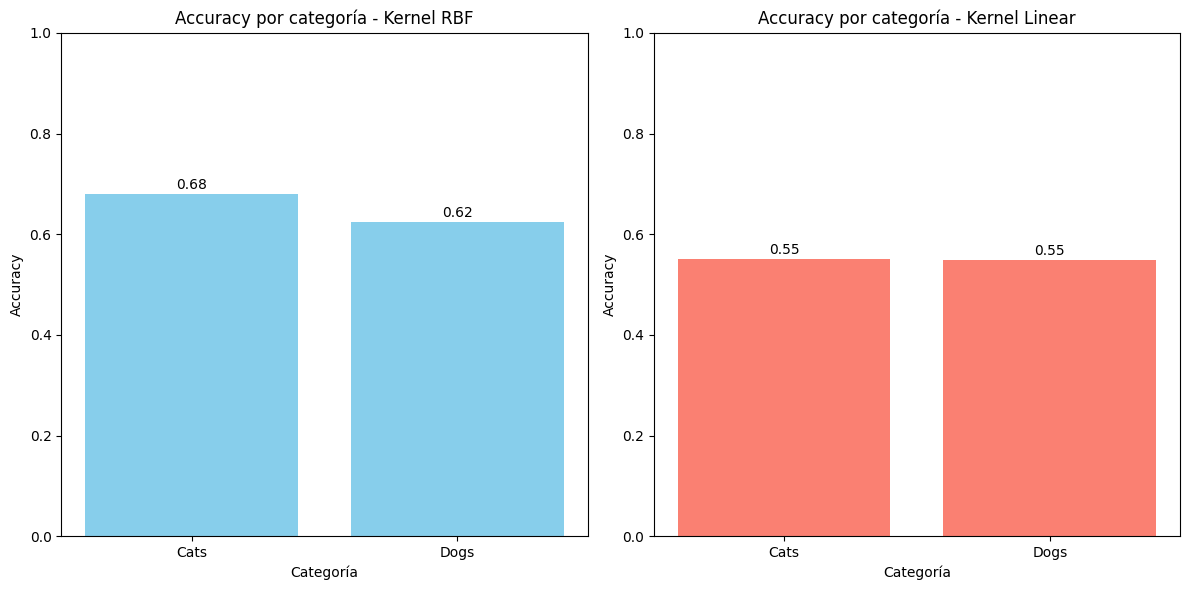

In [28]:
mostrar_resultados_svm(matriz_confusion_rbf, matriz_confusion_linear, accuracy_rbf, accuracy_linear, tiempo_compilacion_rbf, tiempo_compilacion_linear)

<h2>Experimento 2</h2>
A continuación, se prueba el modelo con un kernel RBF y lineal con vectores correspondientes a las imágenes convertidas a vectores de 256 elementos luego de aplicar PCA.

In [ ]:
pipeline_svm_rbf = Pipeline([
    ('escalador', StandardScaler()), 
    ('pca', PCA(n_components=256)),   
    ('svm_rbf', SVC(kernel='rbf', C=1, gamma=0.000625))
])

pipeline_svm_linear = Pipeline([
    ('escalador', StandardScaler()), 
    ('pca', PCA(n_components=256)),   
    ('svm_linear', SVC(kernel='linear', C=10, gamma=0.001))
])

resultados_rbf = evaluar_modelo(
    pipeline_svm_rbf, imagenes_entrenamiento, imagenes_prueba, etiquetas_entrenamiento, etiquetas_prueba, nombre_kernel="RBF"
)
accuracy_rbf, predicciones_rbf, matriz_confusion_rbf, tiempo_compilacion_rbf = resultados_rbf
print(f"Tiempo de compilación para el modelo con kernel RBF: {tiempo_compilacion_rbf:.4f} segundos")

resultados_linear = evaluar_modelo(
    pipeline_svm_linear, imagenes_entrenamiento, imagenes_prueba, etiquetas_entrenamiento, etiquetas_prueba, nombre_kernel="Linear"
)
accuracy_linear, predicciones_linear, matriz_confusion_linear, tiempo_compilacion_linear = resultados_linear
print(f"Tiempo de compilación para el modelo con kernel Linear: {tiempo_compilacion_linear:.4f} segundos")

Precisión en conjunto de prueba con kernel RBF: 0.6520019772614928
Reporte de Clasificación para kernel RBF:
              precision    recall  f1-score   support

       Gatos       0.64      0.68      0.66      1011
      Perros       0.66      0.62      0.64      1012

    accuracy                           0.65      2023
   macro avg       0.65      0.65      0.65      2023
weighted avg       0.65      0.65      0.65      2023

Matriz de Confusión para kernel RBF:
[[687 324]
 [380 632]]
Tiempo de compilación para el modelo con kernel RBF: 37.4366 segundos
Precisión en conjunto de prueba con kernel Linear: 0.5496786950074147
Reporte de Clasificación para kernel Linear:
              precision    recall  f1-score   support

       Gatos       0.55      0.55      0.55      1011
      Perros       0.55      0.55      0.55      1012

    accuracy                           0.55      2023
   macro avg       0.55      0.55      0.55      2023
weighted avg       0.55      0.55      0.55    

<h3>Gráficos de Accuaracy por categoría</h3>

Tabla de resultados:
                            SVM kernel RBF  SVM kernel Linear
0            Accuracy cats        0.679525           0.549951
1            Accuracy dogs        0.624506           0.549407
2           Accuracy total        0.652002           0.549679
3  Tiempo de ejecución [s]       37.436642        5041.294146


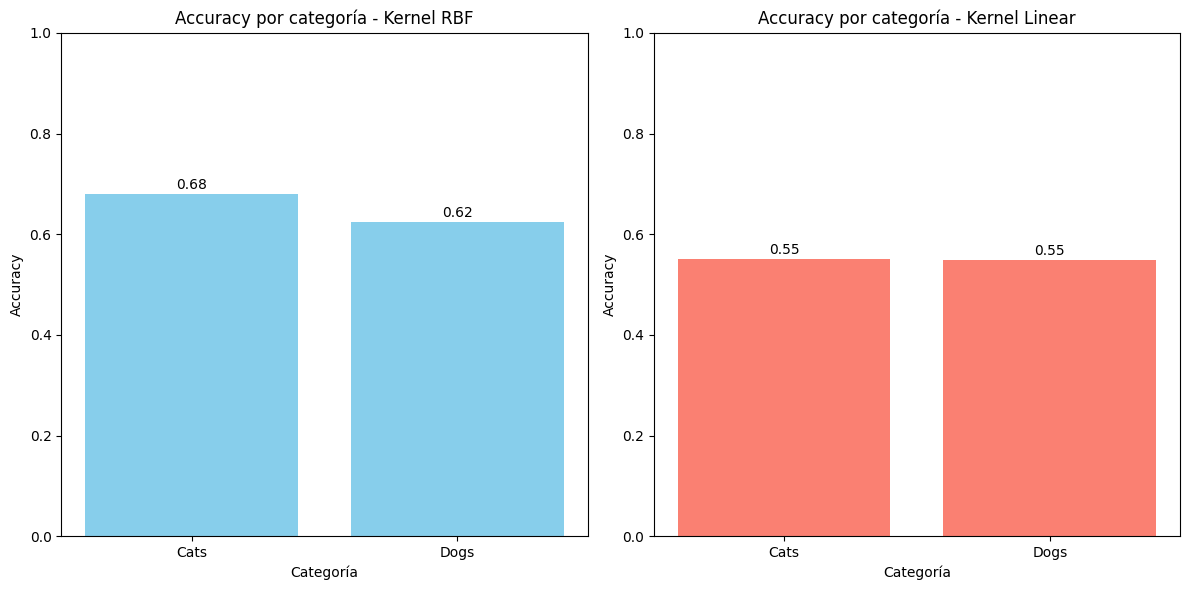

In [29]:
mostrar_resultados_svm(matriz_confusion_rbf, matriz_confusion_linear, accuracy_rbf, accuracy_linear, tiempo_compilacion_rbf, tiempo_compilacion_linear)

<h2>Referencias</h3>

- GeeksforGeeks. (2024, 6 mayo). Radial Basis Function Kernel Machine learning. Geeks For Geeks. https://www-geeksforgeeks-org.translate.goog/radial-basis-function-kernel-machine-learning/?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=rq 
- IBM. (2023a, diciembre 8). PCA. IBM. https://www.ibm.com/es-es/topics/principal-component-analysis
- IBM. (2023b, diciembre 27). Máquina de vector de soporte. IBM. https://www.ibm.com/mx-es/topics/support-vector-machine 
- Sreenivasa, S. (2021, 16 diciembre). Radial Basis Function (RBF) kernel: the Go-To kernel. Medium. https://towardsdatascience.com/radial-basis-function-rbf-kernel-the-go-to-kernel-acf0d22c798a
- Academy, E. (2023, 7 agosto). ¿Cuál es la función del kernel predeterminada en SVM? ¿Se pueden utilizar otras funciones del kernel? Proporcione ejemplos de otras funciones del kernel. - Academia EITCA. EITCA Academy. https://es.eitca.org/artificial-intelligence/eitc-ai-mlp-machine-learning-with-python/support-vector-machine/svm-parameters/examination-review-svm-parameters/what-is-the-default-kernel-function-in-svm-can-other-kernel-functions-be-used-provide-examples-of-other-kernel-functions/